In [179]:
#Import Statement 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import sys

In [180]:
sys.path.append("C:/Users/MSI Modern/Downloads/EDA_on_NOAA_ADAPC_Dataset.csv")

#JupyterNotebook和Python要读取指定本地文件夹方法，只需在代码前增加两行代码：
#import sys
#sys.path.append(D：工作文件) #换成目标路径即可。
#Credit: https://blog.csdn.net/weixin_42508806/article/details/126398690

In [181]:
df= pd.read_csv("C:/Users/MSI Modern/Downloads/EDA_on_NOAA_ADAPC_Dataset.csv")

#Read in the 2018 lightning stirke dataset
#df= pd.read_csv("C:\Users\MSI Modern\Downloads\EDA on NOAA, GADAPC Dataset.csv"), for others such as Jupyter/Pycharm

In [182]:
#Convert 'Date' into datetime

df['date']=pd.to_datetime(df['date'])
df.head()

,date,number_of_strikes,center_point_geom
0,2016-08-05,16,POINT(-101.5 24.7)
1,2016-08-05,16,POINT(-85 34.3)
2,2016-08-05,16,POINT(-89 41.4)
3,2016-08-05,16,POINT(-89.8 30.7)
4,2016-08-05,16,POINT(-86.2 37.9)


In [183]:
df.shape

(10479003, 3)

In [184]:
df.drop_duplicates().shape
#Return the same value afterdroppped the duplicated figure= mean thats no duplicate

(10479003, 3)

In [185]:
#Sort by number of strikes in descending order
df.sort_values(by='number_of_strikes',ascending=False).head(10)

,date,number_of_strikes,center_point_geom
1208433,2016-05-26,2386,POINT(-96.3 30.3)
106830,2017-04-11,2330,POINT(-97.7 31.2)
3323180,2016-08-07,2271,POINT(-84 29)
7441365,2017-04-11,2242,POINT(-97.6 31.2)
2167347,2018-08-20,2211,POINT(-92.5 35.5)
4260229,2018-08-16,2142,POINT(-96.1 36.1)
5397540,2016-05-26,2095,POINT(-96.2 30.3)
6356003,2018-08-17,2061,POINT(-90.2 36.1)
7404862,2018-08-17,2031,POINT(-89.9 35.9)
70627,2018-08-16,1902,POINT(-96.2 36.1)


In [186]:
#Identity locations that appear mot in the dataet 
df.center_point_geom.value_counts()

#.Value counts= Pivot>Count in Excel

center_point_geom
POINT(-77.8 18.3)     320
POINT(-78 18.3)       319
POINT(-82.5 22.9)     311
POINT(-78 18.4)       310
POINT(-77.9 18.3)     310
                     ... 
POINT(-116 25.9)        1
POINT(-115.7 26)        1
POINT(-116.9 27)        1
POINT(-125.4 50.5)      1
POINT(-120 31.4)        1
Name: count, Length: 187145, dtype: int64

In [187]:
#Idemtify top 20 locations with the most days of lightning

df.center_point_geom.value_counts()[:20].rename_axis('Unique_Values').reset_index(name='Counts').style.background_gradient()

,Unique_Values,Counts
0,POINT(-77.8 18.3),320
1,POINT(-78 18.3),319
2,POINT(-82.5 22.9),311
3,POINT(-78 18.4),310
4,POINT(-77.9 18.3),310
5,POINT(-77.7 18.3),303
6,POINT(-78 18.2),302
7,POINT(-84.2 22.3),302
8,POINT(-82.2 22.9),302
9,POINT(-84.1 22.4),302


In [188]:
#Create 2 new columns 
df['week']=df.date.dt.isocalendar().week
df['weekday']=df.date.dt.day_name()
df.head()

,date,number_of_strikes,center_point_geom,week,weekday
0,2016-08-05,16,POINT(-101.5 24.7),31,Friday
1,2016-08-05,16,POINT(-85 34.3),31,Friday
2,2016-08-05,16,POINT(-89 41.4),31,Friday
3,2016-08-05,16,POINT(-89.8 30.7),31,Friday
4,2016-08-05,16,POINT(-86.2 37.9),31,Friday


In [189]:
#Calculate mean count of lightning strikes for each weekday
df[['weekday','number_of_strikes']].groupby(['weekday']).mean()

,number_of_strikes
weekday,
Friday,11.708626
Monday,11.531541
Saturday,11.831304
Sunday,11.689751
Thursday,11.452641
Tuesday,11.344666
Wednesday,11.464647


In [190]:
#Box Plot 
#Data visualization that depicts the locality, spreads and skew of groups of values within quartiles 

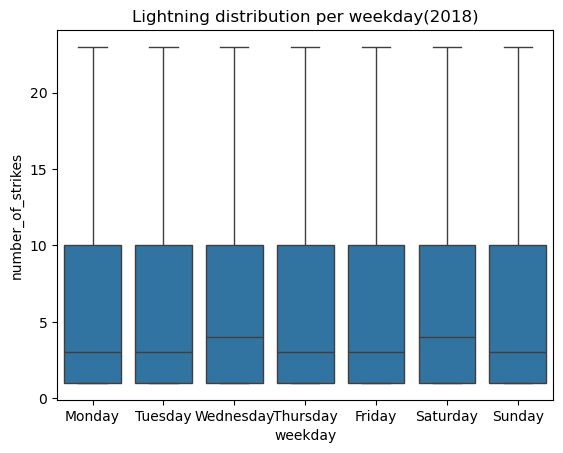

In [191]:
#Define order of days for the plot
weekday_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#Create boxplots of strike counts for each day of week
g= sns.boxplot(data=df,
               x='weekday',
               y='number_of_strikes',
               order=weekday_order,
               showfliers=False
              );

g.set_title('Lightning distribution per weekday(2018)');

#showfliers= Outliers that might or might not be included in the box plot, True= include
#It would not delete those outliers from the dataset, just not show in the graph

In [192]:
#Merging
#Combine 2 different data sources into one

In [193]:
#Create new dataframe combining 2016-2017 data with 2018 data

#union_df= pd.concat([df.drop(['weekday','week'],axis=1),df_2], ignore_index=True)
#union_df.head()

#To make 2 data set consistent, DF1 use df.drop to remove 'weekday','week' column
#To combine the dataset, use pd.concat

In [194]:
df['month']= df['date'].dt.month
df['month_txt']= df['date'].dt.month_name().str.slice(stop=3)
df['year']= df['date'].dt.year
df.head()

#Add 3 Date column to better grouping

,date,number_of_strikes,center_point_geom,week,weekday,month,month_txt,year
0,2016-08-05,16,POINT(-101.5 24.7),31,Friday,8,Aug,2016
1,2016-08-05,16,POINT(-85 34.3),31,Friday,8,Aug,2016
2,2016-08-05,16,POINT(-89 41.4),31,Friday,8,Aug,2016
3,2016-08-05,16,POINT(-89.8 30.7),31,Friday,8,Aug,2016
4,2016-08-05,16,POINT(-86.2 37.9),31,Friday,8,Aug,2016


In [195]:
df[['year','number_of_strikes',]].groupby(['year']).sum()

#[[]] To 'SELECT' only the 2 column wanted to show like in SQL
#Then grouby year

,number_of_strikes
year,
2016,41582229
2017,35095195
2018,44600989


In [196]:
#look into the % change for each month
 
lightning_by_month= df.groupby(['month_txt','year']).agg(
    number_of_strikes= pd.NamedAgg(column='number_of_strikes', aggfunc=sum)
).reset_index()

lightning_by_month.head()

#Agg is used to aggregate according to which 'Column', and the aggregate function= sum
#So that can obtain the sum of every month from each year

C:\Users\MSI Modern\AppData\Local\Temp\ipykernel_12384\2808079754.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  lightning_by_month= df.groupby(['month_txt','year']).agg(


,month_txt,year,number_of_strikes
0,Apr,2016,2636427
1,Apr,2017,3819075
2,Apr,2018,1524339
3,Aug,2016,7250442
4,Aug,2017,6021702


In [197]:
lightning_by_year= df.groupby(['year']).agg(
    number_of_strikes= pd.NamedAgg(column='number_of_strikes', aggfunc=sum)
).reset_index()

lightning_by_year.head()

#Aggregate by year

C:\Users\MSI Modern\AppData\Local\Temp\ipykernel_12384\2211235897.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  lightning_by_year= df.groupby(['year']).agg(


,year,number_of_strikes
0,2016,41582229
1,2017,35095195
2,2018,44600989


In [198]:
percentage_lightning= lightning_by_month.merge(lightning_by_year, on= 'year')

percentage_lightning.head()

#Using 'year' as indicator to combine 2 Df

,month_txt,year,number_of_strikes_x,number_of_strikes_y
0,Apr,2016,2636427,41582229
1,Apr,2017,3819075,35095195
2,Apr,2018,1524339,44600989
3,Aug,2016,7250442,41582229
4,Aug,2017,6021702,35095195


In [199]:
percentage_lightning['persentage_lightning_per_month']= ((percentage_lightning.number_of_strikes_x/percentage_lightning.number_of_strikes_y)*100)

percentage_lightning.head()

,month_txt,year,number_of_strikes_x,number_of_strikes_y,persentage_lightning_per_month
0,Apr,2016,2636427,41582229,6.340273
1,Apr,2017,3819075,35095195,10.882045
2,Apr,2018,1524339,44600989,3.417725
3,Aug,2016,7250442,41582229,17.436396
4,Aug,2017,6021702,35095195,17.158195


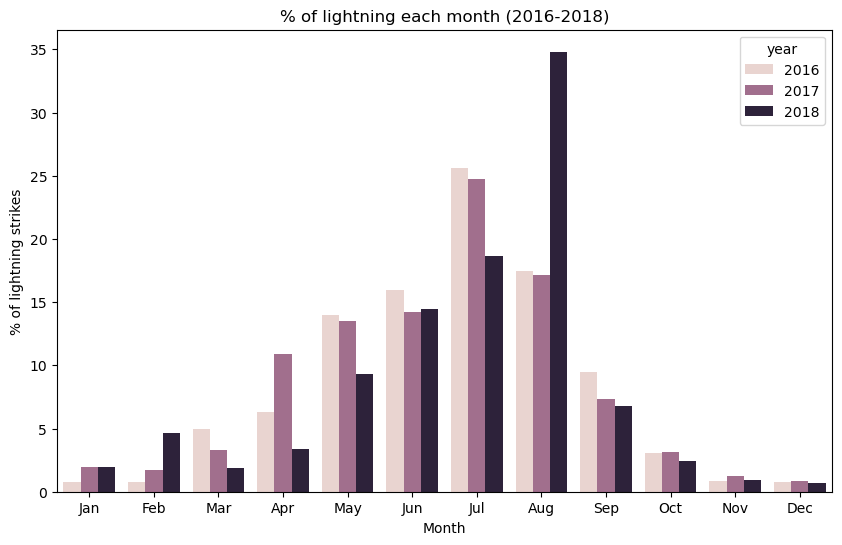

In [200]:
month_order= ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,6));

sns.barplot(
    data= percentage_lightning,
    x= 'month_txt',
    y= 'persentage_lightning_per_month',
    hue= 'year',
    order = month_order);

plt.xlabel('Month')
plt.ylabel('% of lightning strikes')
plt.title('% of lightning each month (2016-2018)');